In [1]:
import pandas as pd
import geopandas as gpd
import glob
import os
from shapely import wkt

In [5]:
##get csv files for calls for service
path = './data/calls_for_service/2021' # change to your path
files_2021 = glob.glob(path + "/*.csv")

# 2. Read each file and combine them into one DataFrame
calls_for_service_2021 = pd.concat((pd.read_csv(f) for f in files_2021), ignore_index=True)

calls_for_service_2021.head()

,OBJECTID,CAD_EVNT_ID,CREATE_DATE,INCIDENT_DATE,INCIDENT_TIME,NYPD_PCT_CD,BORO_NM,PATRL_BORO_NM,GEO_CD_X,GEO_CD_Y,RADIO_CODE,TYP_DESC,CIP_JOBS,ADD_TS,DISP_TS,ARRIVD_TS,CLOSNG_TS,Latitude,Longitude,Location
0,NaN,80211268,10/01/2021,10/01/2021,04:48:28,14.0,MANHATTAN,PATROL BORO MAN SOUTH,987220,212676,56S9,VERIFY AMB NEEDED: TRANSIT,Non CIP,2021 Oct 01 04:48:28 AM,2021 Oct 01 04:48:28 AM,2021 Oct 01 04:48:28 AM,2021 Oct 01 04:56:14 AM,40.750431,-73.989282,POINT (-73.989282 40.750431)
1,NaN,80209851,10/01/2021,10/01/2021,02:18:22,19.0,MANHATTAN,PATROL BORO MAN NORTH,994813,216076,75D,VISIBILITY PATROL: DIRECTED,Non CIP,2021 Oct 01 02:18:22 AM,2021 Oct 01 02:18:22 AM,2021 Oct 01 02:18:22 AM,2021 Oct 01 02:46:37 AM,40.759757,-73.961872,POINT (-73.961872 40.759757)
2,NaN,80212216,10/01/2021,10/01/2021,06:30:28,110.0,QUEENS,PATROL BORO QUEENS NORTH,1022688,209132,75D,VISIBILITY PATROL: DIRECTED,Non CIP,2021 Oct 01 06:30:28 AM,2021 Oct 01 06:30:28 AM,2021 Oct 01 06:30:28 AM,2021 Oct 01 07:19:12 AM,40.740620,-73.861292,POINT (-73.861292 40.74062)
3,NaN,80211018,10/01/2021,10/01/2021,04:19:55,75.0,BROOKLYN,PATROL BORO BKLYN NORTH,1012960,182222,75D,VISIBILITY PATROL: DIRECTED,Non CIP,2021 Oct 01 04:19:55 AM,2021 Oct 01 04:19:55 AM,2021 Oct 01 04:19:55 AM,2021 Oct 01 04:55:58 AM,40.666796,-73.896512,POINT (-73.896512 40.666796)
4,NaN,80208018,10/01/2021,10/01/2021,00:15:19,23.0,MANHATTAN,PATROL BORO MAN NORTH,1000778,226841,75D,VISIBILITY PATROL: DIRECTED,Non CIP,2021 Oct 01 12:15:19 AM,2021 Oct 01 12:15:20 AM,2021 Oct 01 12:15:20 AM,2021 Oct 01 12:54:49 AM,40.789295,-73.940314,POINT (-73.940314 40.789295)


In [7]:
# Convert arrest date to datetime
calls_for_service_2021["INCIDENT_DATE"] = pd.to_datetime(calls_for_service_2021["INCIDENT_DATE"], errors="coerce")

In [11]:
# Create year and month columns
calls_for_service_2021["year"] = calls_for_service_2021["INCIDENT_DATE"].dt.year
calls_for_service_2021["month"] = calls_for_service_2021["INCIDENT_DATE"].dt.month

In [13]:
# Keep only rows with valid date
calls_for_service_2021 = calls_for_service_2021.dropna(subset=["Latitude", "Longitude"]).copy()
print(calls_for_service_2021.shape)

(6707027, 22)


In [21]:
count = calls_for_service_2021['CAD_EVNT_ID'].nunique()
print(count)

6493922


In [25]:
# Create year and month columns
calls_geo = gpd.GeoDataFrame(
    calls_for_service_2021,
    geometry=gpd.points_from_xy(calls_for_service_2021["Longitude"], calls_for_service_2021["Latitude"]),
    crs="EPSG:4326"
)

calls_geo.head()

,OBJECTID,CAD_EVNT_ID,CREATE_DATE,INCIDENT_DATE,INCIDENT_TIME,NYPD_PCT_CD,BORO_NM,PATRL_BORO_NM,GEO_CD_X,GEO_CD_Y,...,ADD_TS,DISP_TS,ARRIVD_TS,CLOSNG_TS,Latitude,Longitude,Location,year,month,geometry
0,NaN,80211268,10/01/2021,2021-10-01,04:48:28,14.0,MANHATTAN,PATROL BORO MAN SOUTH,987220,212676,...,2021 Oct 01 04:48:28 AM,2021 Oct 01 04:48:28 AM,2021 Oct 01 04:48:28 AM,2021 Oct 01 04:56:14 AM,40.750431,-73.989282,POINT (-73.989282 40.750431),2021,10,POINT (-73.989 40.75)
1,NaN,80209851,10/01/2021,2021-10-01,02:18:22,19.0,MANHATTAN,PATROL BORO MAN NORTH,994813,216076,...,2021 Oct 01 02:18:22 AM,2021 Oct 01 02:18:22 AM,2021 Oct 01 02:18:22 AM,2021 Oct 01 02:46:37 AM,40.759757,-73.961872,POINT (-73.961872 40.759757),2021,10,POINT (-73.962 40.76)
2,NaN,80212216,10/01/2021,2021-10-01,06:30:28,110.0,QUEENS,PATROL BORO QUEENS NORTH,1022688,209132,...,2021 Oct 01 06:30:28 AM,2021 Oct 01 06:30:28 AM,2021 Oct 01 06:30:28 AM,2021 Oct 01 07:19:12 AM,40.740620,-73.861292,POINT (-73.861292 40.74062),2021,10,POINT (-73.861 40.741)
3,NaN,80211018,10/01/2021,2021-10-01,04:19:55,75.0,BROOKLYN,PATROL BORO BKLYN NORTH,1012960,182222,...,2021 Oct 01 04:19:55 AM,2021 Oct 01 04:19:55 AM,2021 Oct 01 04:19:55 AM,2021 Oct 01 04:55:58 AM,40.666796,-73.896512,POINT (-73.896512 40.666796),2021,10,POINT (-73.897 40.667)
4,NaN,80208018,10/01/2021,2021-10-01,00:15:19,23.0,MANHATTAN,PATROL BORO MAN NORTH,1000778,226841,...,2021 Oct 01 12:15:19 AM,2021 Oct 01 12:15:20 AM,2021 Oct 01 12:15:20 AM,2021 Oct 01 12:54:49 AM,40.789295,-73.940314,POINT (-73.940314 40.789295),2021,10,POINT (-73.94 40.789)


In [27]:
blocks = pd.read_csv("./data/2020_Census_Blocks_nyc.csv")

print(blocks.columns.tolist())
blocks.head()

['the_geom', 'CB2020', 'BoroCode', 'BoroName', 'CT2020', 'BCTCB2020', 'GEOID', 'Shape_Length', 'Shape_Area']


,the_geom,CB2020,BoroCode,BoroName,CT2020,BCTCB2020,GEOID,Shape_Length,Shape_Area
0,MULTIPOLYGON (((-74.03995040788483 40.70089063...,1000,1,Manhattan,100,10001001000,360610001001000,"6,437.85374521","1,202,838.17013"
1,MULTIPOLYGON (((-74.04387761639944 40.69018767...,1001,1,Manhattan,100,10001001001,360610001001001,"4,395.19018343","640,166.352288"
2,MULTIPOLYGON (((-73.98495042073655 40.71235553...,2000,1,Manhattan,201,10002012000,360610002012000,"2,055.29576202","263,308.402003"
3,MULTIPOLYGON (((-73.9799619880113 40.713972699...,1000,1,Manhattan,202,10002021000,360610002021000,"1,187.88411083","57,115.9366413"
4,MULTIPOLYGON (((-73.98187417339794 40.71144411...,2000,1,Manhattan,202,10002022000,360610002022000,"2,178.77742688","157,313.542923"


In [29]:
# Convert WKT geometry string to shapely geometry
blocks.columns = blocks.columns.str.strip()
blocks["geometry"] = blocks["the_geom"].apply(wkt.loads)

blocks_geo = gpd.GeoDataFrame(
    blocks,
    geometry="geometry",
    crs="EPSG:4326"
)

# Keep only useful columns
blocks_geo = blocks_geo[[
    "CB2020", "BoroName", "CT2020", "BCTCB2020", "geometry"
]].copy()

blocks_geo.head()

,CB2020,BoroName,CT2020,BCTCB2020,geometry
0,1000,Manhattan,100,10001001000,"MULTIPOLYGON (((-74.04 40.701, -74.039 40.701,..."
1,1001,Manhattan,100,10001001001,"MULTIPOLYGON (((-74.044 40.69, -74.044 40.69, ..."
2,2000,Manhattan,201,10002012000,"MULTIPOLYGON (((-73.985 40.712, -73.985 40.712..."
3,1000,Manhattan,202,10002021000,"MULTIPOLYGON (((-73.98 40.714, -73.979 40.714,..."
4,2000,Manhattan,202,10002022000,"MULTIPOLYGON (((-73.982 40.711, -73.982 40.711..."


In [31]:
print(calls_geo.crs)
print(blocks_geo.crs)

EPSG:4326
EPSG:4326


In [33]:
# predicate="within" means each call point must fall within a block polygon
calls_with_block = gpd.sjoin(
    calls_geo,
    blocks_geo,
    how="left",
    predicate="within"
)

print(calls_with_block.shape)
calls_with_block[["year", "month", "CAD_EVNT_ID", "INCIDENT_DATE", "CB2020"]].head()

(6707027, 28)


,year,month,CAD_EVNT_ID,INCIDENT_DATE,CB2020
0,2021,10,80211268,2021-10-01,1006.0
1,2021,10,80209851,2021-10-01,6003.0
2,2021,10,80212216,2021-10-01,1005.0
3,2021,10,80211018,2021-10-01,2001.0
4,2021,10,80208018,2021-10-01,3000.0


In [35]:
calls_grouped = (
    calls_with_block
    .dropna(subset=["CB2020"])
    .groupby(["year", "month", "CB2020", "BoroName", "CT2020", "BCTCB2020"], as_index=False)
    .agg(total_calls=("CAD_EVNT_ID", "count"))
)
print(calls_grouped.head())

   year  month  CB2020   BoroName    CT2020     BCTCB2020  total_calls
0  2021      1     1.0   Brooklyn  102802.0  3.102802e+10            9
1  2021      1     1.0  Manhattan   16300.0  1.016300e+10            2
2  2021      1     2.0  Manhattan   13501.0  1.013501e+10            3
3  2021      1  1000.0      Bronx     100.0  2.000100e+10            2
4  2021      1  1000.0      Bronx     200.0  2.000200e+10            4


In [37]:
# Full joined file if you want to inspect individual arrests after matching
calls_with_block.to_csv('./data/output/calls_with_census_block.csv', index=False)

# Final required arrest-level aggregated dataset
calls_grouped.to_csv('./data/output/final_calls_by_block_month_year.csv', index=False)

In [17]:
# Map
def clean_geoid(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if x.endswith(".0"):
        x = x[:-2]
    return x

In [18]:
blocks_geo["GEOID"] = blocks_geo["GEOID"].apply(clean_geoid)
calls_grouped["GEOID"] = calls_grouped["GEOID"].apply(clean_geoid)

In [21]:
calls_filtered = calls_grouped[
    calls_grouped["year"].isin([2020, 2021])
]
total_calls_all = (
    calls_filtered
    .groupby("GEOID", as_index=False)
    .agg(total_calls=("total_calls", "sum"))
)

print(total_calls_all.head())

             GEOID  total_calls
0  360050001001000            0
1  360050001001001           27
2  360050001001002           13
3  360050001001003            8
4  360050002001000           47


In [22]:
map_data = blocks_geo.merge(total_calls_all, on="GEOID", how="left")

map_data["total_calls"] = map_data["total_calls"].fillna(0)

print(map_data["total_calls"].describe())

count    37588.000000
mean       101.470416
std        300.525340
min          0.000000
25%          9.000000
50%         29.000000
75%         88.000000
max      21197.000000
Name: total_calls, dtype: float64


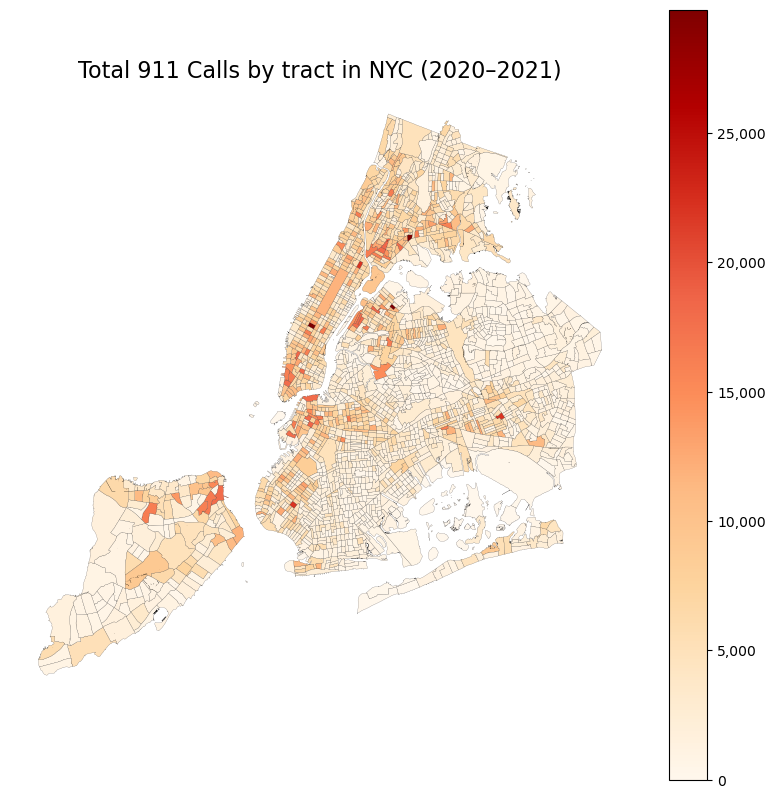

In [31]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# arregate to tract level
tract_map = map_data.dissolve(
    by="CT2020",
    aggfunc={"total_calls": "sum"}
)

fig, ax = plt.subplots(figsize=(10, 10))

tract_map.plot(
    column="total_calls",
    cmap="OrRd",
    legend=True,
    vmin=0,
    vmax=tract_map["total_calls"].max(), 
    edgecolor="black",
    linewidth=0.1,
    ax=ax
)

cbar_ax = ax.get_figure().axes[-1]
cbar_ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))

ax.set_title("Total 911 Calls by tract in NYC (2020–2021)", fontsize=16)
ax.axis("off")

plt.savefig("borough_calls.pdf", bbox_inches="tight")
plt.show()

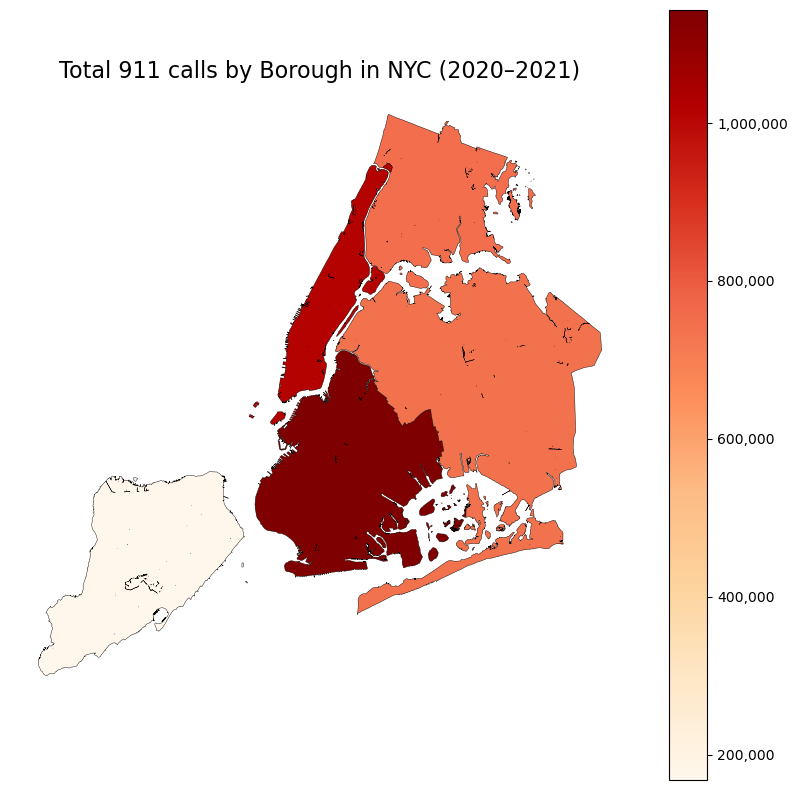

In [32]:
# borough level
borough_map = map_data.dissolve(
    by="BoroName",
    aggfunc={"total_calls": "sum"}
)

fig, ax = plt.subplots(figsize=(10, 10))

borough_map.plot(
    column="total_calls",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

cbar_ax = ax.get_figure().axes[-1]
cbar_ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))

ax.set_title("Total 911 calls by Borough in NYC (2020–2021)", fontsize=16)
ax.axis("off")

plt.savefig("borough_calls.pdf", bbox_inches="tight")
plt.show()